# 💧 Generate and Explore Continuum Forcing Data
<br>
<img style="float: left; padding-right: 15px; padding-left: 0px;" src="../sources/images/logo_continuum.png" width="260px" align=”left” >

<div style="text-align: justify">
This notebook:
    
- reads a JSON configuration file (e.g. `melkaAwash_dynamic.json`);
- loads the **choice** raster specified in the configuration to derive a bounding box;
- asks the user to define a **start** and **end** time for the forcing period;
- calls `forcing_tools.convert_forcing` to generate the forcing data on the selected bounding box;
- provides a set of **analysis utilities** to:
  - plot time series of different variables at a **single point**;
  - plot **basin‑average** (mask = non‑null cells of the choice raster, i.e. `values > -9999`);
  - plot **average** maps (or **cumulative** maps for rainfall) over a user‑defined sub‑period.

> 📝 The code is deliberately verbose and commented so that you can easily adapt it to other projects/domains.


## 🔧 Preliminary Setup

This section defines the configuration file, imports the required libraries,
and prepares the project paths using the JSON settings file.


### Specify configuration file

Edit the line below if you want to use a different JSON settings file.


In [1]:
# Name of the JSON configuration file
# (must be located in the `settings` folder at the project root)
settings_file = "awashOmbole_dynamic.json"

print(f"Using settings file: {settings_file}")

Using settings file: awashOmbole_dynamic.json


### Import required libraries

In [2]:
import os
import json
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import rasterio as rio
import geopandas as gpd
import matplotlib.pyplot as plt

from IPython.display import display, clear_output

# Local project tools (must be importable from PYTHONPATH / local folder)
import forcing_tools

# Plotting backend for interactive work (optional)
%matplotlib inline

plt.close("all")
print("All required libraries have been imported.")

All required libraries have been imported.


## 📁 Load configuration and set up paths

This cell:

1. Detects the **project root** (assuming this notebook lives inside `notebook_continuum/`).
2. Loads the JSON configuration file.
3. Builds the full paths listed in the `path` section of the configuration
   under `<project_root>/projects/<project_name>/...`.


In [3]:
# Detect the project root (parent of the `notebook_continuum` folder)
project_root = str(Path().cwd()).replace('notebook_continuum', '')

# Load configuration from the JSON file
settings_path = os.path.join(project_root, "settings", settings_file)
with open(settings_path, "r") as f:
    config = json.load(f)

print(f"Configuration loaded from: {settings_path}")

# Generate folder tree based on the configuration
path_settings = config["path"].copy()
for key in path_settings.keys():
    path_settings[key] = os.path.join(
        project_root, "projects", config["general"]["project"], path_settings[key]
    )
    os.makedirs(path_settings[key], exist_ok=True)

dataset_folder_raw = "/sources/datasets"
dataset_folder = project_root + dataset_folder_raw

print("Folder tree generated successfully.")
print(f"Project root: {project_root}")
print("Resolved paths:")
for k, v in path_settings.items():
    print(f"  - {k}: {v}")

Configuration loaded from: /home/continuumuser/workdir/settings/awashOmbole_dynamic.json
Folder tree generated successfully.
Project root: /home/continuumuser/workdir/
Resolved paths:
  - gridded_input: /home/continuumuser/workdir/projects/awashOmbole_iwrm/continuum/data_geo/gridded
  - output: /home/continuumuser/workdir/projects/awashOmbole_iwrm/continuum/data_forcing/input/ERA-CHIRPS/


## 🗺️ Load choice raster and derive bounding box

The **choice** raster specified in the JSON file is used to:

- derive the **bounding box** to pass to `forcing_tools.convert_forcing`;
- define a **basin mask**, given by cells where `value > -9999`.

The code assumes that the choice raster is located under
`path_settings["gridded_input"]` and that `config["data"]["choice"]`
contains its file name.


Choice raster path: /home/continuumuser/workdir/projects/awashOmbole_iwrm/continuum/data_geo/gridded/awashOmbole.choice.txt
Derived bounding box from choice raster: [37.736155947778, 8.043363833333002, 39.351314744178, 9.577583684833]


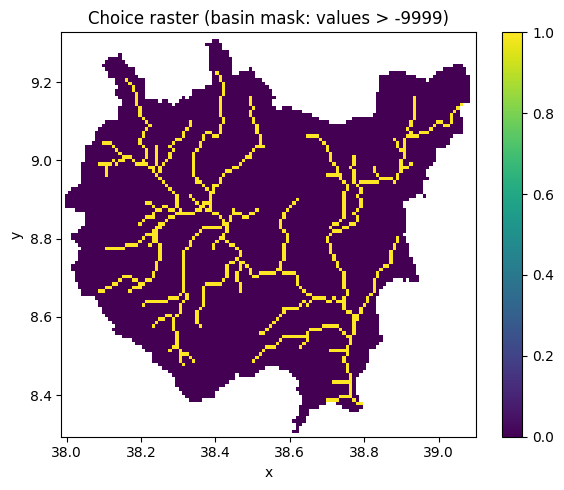

In [4]:
# Build the full path to the choice raster
choice_raster_path = os.path.join(
    path_settings["gridded_input"],
    config["data"]["choice"],
)

print(f"Choice raster path: {choice_raster_path}")

# Load the raster (any GDAL/rasterio‑readable format)
choice_da = rxr.open_rasterio(choice_raster_path, masked=True).squeeze()
choice_da = choice_da.rio.write_crs("EPSG:4326")
# Define basin mask: valid cells are those with value > -9999
basin_mask_raw = choice_da.where(choice_da > -9999)

# Bounding box (xmin, ymin, xmax, ymax) in EPSG:4326
xmin, ymin, xmax, ymax = basin_mask_raw.rio.bounds()
bbox = [float(xmin) - 0.25, float(ymin) - 0.25, float(xmax) + 0.25, float(ymax) + 0.25]

print(f"Derived bounding box from choice raster: {bbox}")

# Quick visualization of the basin mask
fig, ax = plt.subplots(figsize=(6, 5))
basin_mask_raw.plot(ax=ax)
ax.set_title("Choice raster (basin mask: values > -9999)")
plt.tight_layout()
plt.show()

## 🛑 **WARNING! Copy all required data from the `meteo_dataset` on the USB stick for the period of interest to the `datasets` folder before proceeding** 🛑
In particular, for all the years falling in the period of analysis you should copy:

- ERA5 netcdf files for all the variables direcly in the `workspace\sources\datasets\ERA5` folder
- The folder contaning the year CHIRPS data (all the folder) for the years of interest in the `workspace\sources\datasets\CHIRPS` folder

## ⏱️ Define forcing period and input templates

In this section you:

1. Choose the **time window** for the forcing generation (`start` / `end`).
2. Define the input file templates for ERA5 and CHIRPS data.
3. Define the output directory template.

> ⚠️ **Important:**  
> Before starting the making of forcing be sure that you have copied the CHIRPS and ERA5 dataset for the period of interest from the **meteorological_dataset** of the USB-disk to the **workspace\sources\datasets** directory on your laptop. In particular:
> - All the yearly folder of CHIRPS of interest should be copied to **workspace\sources\datasets\CHIRPS**
> - All the ERA5 dataset for the years of interest should be copied to **workspace\sources\datasets\ERA5**


In [5]:
# --- 1. Time window for forcing generation ---------------------------------

# Time format expected by `forcing_tools.convert_forcing`
time_fmt = "%d-%m-%Y %H:%M"

# 👉 EDIT THESE STRINGS to select your forcing period
time_start = "01-07-2001 00:00"  # DD-MM-YYYY HH:MM
time_end   = "31-12-2002 23:00"

print(f"Requested forcing period: {time_start} → {time_end}")

# --- 2. Input templates (EDIT to match your data layout) -------------------

# Base folder where gridded input data live
gridded_root = path_settings["gridded_input"]

# Examples below are just placeholders: adjust subfolders / file names
era5_T_template    = os.path.join(dataset_folder, "ERA5", "ETH_T_%Y.nc")
era5_P_template    = os.path.join(dataset_folder, "ERA5", "ETH_P_%Y.nc")
era5_R_template    = os.path.join(dataset_folder, "ERA5", "ETH_R_%Y.nc")
era5_Ux_template   = os.path.join(dataset_folder, "ERA5", "ETH_Ux_%Y.nc")
era5_Vx_template   = os.path.join(dataset_folder, "ERA5", "ETH_Vx_%Y.nc")
era5_Tdew_template = os.path.join(dataset_folder, "ERA5", "ETH_Tdew_%Y.nc")

chirps_pattern_template = os.path.join(
    dataset_folder,
    "CHIRPS",
    "%Y",
    "%m",
    "CHIRPS-precip1d_ETH_%Y%m*.tif",
)

# --- 3. Output directory template -----------------------------------------

output_root = path_settings["output"]
output_dir_template = output_root
# Output directory structure: one folder for each year/month
# (this must match the expectations inside forcing_tools.convert_forcing)
print("Example resolved paths (for 2000-01):")
import datetime as _dt
_ref = _dt.datetime(2000, 1, 1)
print("  ERA5 T file: ", _ref.strftime(era5_T_template))
print("  CHIRPS glob:", _ref.strftime(chirps_pattern_template))
print("  Output dir: ", _ref.strftime(output_dir_template))

Requested forcing period: 01-07-2001 00:00 → 31-07-2003 23:00
Example resolved paths (for 2000-01):
  ERA5 T file:  /home/continuumuser/workdir//sources/datasets/ERA5/ETH_T_2000.nc
  CHIRPS glob: /home/continuumuser/workdir//sources/datasets/CHIRPS/2000/01/CHIRPS-precip1d_ETH_200001*.tif
  Output dir:  /home/continuumuser/workdir/projects/awashOmbole_iwrm/continuum/data_forcing/input/ERA-CHIRPS/


## ▶️ Run forcing generation

This cell calls `forcing_tools.convert_forcing` using:

- the time window (`time_start`, `time_end`);
- the input templates defined above;
- the `bbox` derived from the choice raster.

> ⚠️ This step may take some time depending on the size of the domain,
> the length of the period and I/O performance.


In [6]:
# Run the forcing conversion
# (edit the paths in the previous cell before executing this one)

forcing_tools.convert_forcing(
    start_str=time_start,
    end_str=time_end,
    era5_T_template=era5_T_template,
    era5_P_template=era5_P_template,
    era5_R_template=era5_R_template,
    era5_Ux_template=era5_Ux_template,
    era5_Vx_template=era5_Vx_template,
    era5_Tdew_template=era5_Tdew_template,
    chirps_pattern_template=chirps_pattern_template,
    output_dir_template=output_dir_template,
    bbox=bbox,
    time_fmt=time_fmt,
)

2025-11-26 20:50:30,517 [INFO] == Forcing conversion from 2001-07-01 00:00:00 to 2003-07-31 23:00:00 ==
2025-11-26 20:50:30,522 [INFO] 
================ 2001-07 (tag 072001) ================
2025-11-26 20:50:30,523 [INFO] Loading ERA5 yearly data for 2001...
2025-11-26 20:50:30,523 [INFO]   ERA5 files:
2025-11-26 20:50:30,524 [INFO]     T:     /home/continuumuser/workdir//sources/datasets/ERA5/ETH_T_2001.nc
2025-11-26 20:50:30,525 [INFO]     P:     /home/continuumuser/workdir//sources/datasets/ERA5/ETH_P_2001.nc
2025-11-26 20:50:30,526 [INFO]     R:     /home/continuumuser/workdir//sources/datasets/ERA5/ETH_R_2001.nc
2025-11-26 20:50:30,526 [INFO]     Ux:    /home/continuumuser/workdir//sources/datasets/ERA5/ETH_Ux_2001.nc
2025-11-26 20:50:30,527 [INFO]     Vx:    /home/continuumuser/workdir//sources/datasets/ERA5/ETH_Vx_2001.nc
2025-11-26 20:50:30,528 [INFO]     Tdew:  /home/continuumuser/workdir//sources/datasets/ERA5/ETH_Tdew_2001.nc
2025-11-26 20:51:28,672 [INFO]   ERA5 yearly data

FileNotFoundError: [Errno 2] No such file or directory: '/home/continuumuser/workdir/sources/datasets/ERA5/ETH_T_2003.nc'

This cell read the climatological LAI in tif format and crop it to the domain bounding box

In [7]:
# Build pattern: LAI/mm/dd/CLIM_*_LAI_clip_bbox_ETH.tif
lai_root = os.path.join(dataset_folder, "LAI")
pattern = os.path.join(lai_root, "*", "*", "CLIM_*_LAI_clip_bbox_ETH.tif")

# Output root folder (mirrors structure under LAI/)
out_folder_lai = path_settings["output"].replace("ERA-CHIRPS", "LAI")
os.makedirs(out_folder_lai, exist_ok=True)

last_logged_month = None  # to log only once per month

for f in sorted(glob(pattern)):
    # Relative path from LAI root, e.g. "03/21/CLIM_0321_LAI_clip_bbox_ETH.tif"
    rel_path = os.path.relpath(f, lai_root)
    parts = rel_path.split(os.sep)

    # Expect: [month, day, filename]
    month = parts[0]

    # Log only once per month
    if month != last_logged_month:
        print(f"Clipping climatological LAI for month {month}")
        last_logged_month = month

    # Read GeoTIFF
    da = rxr.open_rasterio(f)

    # Ensure CRS
    if da.rio.crs is None:
        da = da.rio.write_crs("EPSG:4326")

    # Crop with bbox
    da_crop = da.rio.clip_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
    )

    # Recreate folder structure under out_folder_lai (e.g. LAI/03/21/)
    rel_dir = os.path.dirname(rel_path)      # "03/21"
    out_dir = os.path.join(out_folder_lai, rel_dir)
    os.makedirs(out_dir, exist_ok=True)

    # Output filename with same basename
    out_file = os.path.join(out_dir, os.path.basename(f))

    # Save cropped raster
    da_crop.rio.to_raster(out_file)

Clipping climatological LAI for month 01
Clipping climatological LAI for month 02
Clipping climatological LAI for month 03
Clipping climatological LAI for month 04
Clipping climatological LAI for month 05
Clipping climatological LAI for month 06
Clipping climatological LAI for month 07
Clipping climatological LAI for month 08
Clipping climatological LAI for month 09
Clipping climatological LAI for month 10
Clipping climatological LAI for month 11
Clipping climatological LAI for month 12


## 📦 Helper utilities for loading forcing data

The following functions help you to:

- load all NetCDF files for a given variable (`temperature`, `solar_radiation`,
  `wind`, `relative_humidity`, `total_precipitation`, ...);
- derive a **basin mask** on the same grid as the chosen variable.


In [8]:
def load_forcing_variable(var_name: str, output_root: str = None) -> xr.DataArray:
    """Load all NetCDF files for a given forcing variable.

    Parameters
    ----------
    var_name : str
        Name of the variable (e.g. 'temperature', 'solar_radiation',
        'wind', 'relative_humidity', 'total_precipitation').
    output_root : str, optional
        Root folder for forcing data. If None, `path_settings["output"]` is used.

    Returns
    -------
    xr.DataArray
        Concatenated time series for the requested variable.
    """
    if output_root is None:
        output_root = path_settings["output"]

    pattern = os.path.join(output_root, f"{var_name}_*.nc")
    files = sorted(glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"No NetCDF files found for variable '{var_name}' with pattern: {pattern}"
        )

    print(f"Loading {len(files)} file(s) for variable '{var_name}'...")
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds[var_name]
    da.name = var_name

    # set crs and spatial dims
    da = da.rio.write_crs('EPSG:4326')
    da = da.rio.set_spatial_dims('x', 'y')

    print(f"Loaded dataset with {da.time.size} time steps.")
    return da


def get_basin_mask_on_grid(template_da: xr.DataArray) -> xr.DataArray:
    """Return the basin mask (True/False) on the grid of `template_da`.

    The mask is derived from the choice raster (values > -9999) and
    reprojected/resampled to match the grid of `template_da`.

    Parameters
    ----------
    template_da : xr.DataArray
        Any DataArray whose grid (x/y) will be used as reference.

    Returns
    -------
    xr.DataArray (dtype=bool)
        Basin mask aligned with `template_da`.
    """
    # Reproject basin mask to the template grid
    mask_resampled = basin_mask_raw.rio.reproject_match(template_da)
    basin_mask = ~np.isnan(mask_resampled)
    basin_mask.name = "basin_mask"
    return basin_mask

## 📈 Time series analysis

This section shows how to:

1. Plot the time series of a variable at a **single point** (nearest grid cell).
2. Plot the **basin‑average** time series using the basin mask.


In [9]:
# 👉 Choose the variable to analyse
#   - 'temperature'
#   - 'solar_radiation'
#   - 'wind'
#   - 'relative_humidity'
#   - 'total_precipitation'
var_name = "total_precipitation"

da = load_forcing_variable(var_name)

print(da)

Loading 18 file(s) for variable 'total_precipitation'...
Loaded dataset with 13176 time steps.
<xarray.DataArray 'total_precipitation' (time: 13176, y: 31, x: 32)> Size: 105MB
dask.array<concatenate, shape=(13176, 31, 32), dtype=float64, chunksize=(744, 31, 32), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 105kB 2001-07-01 ... 2002-12-31T23:00:00
  * y            (y) float64 248B 9.575 9.525 9.475 9.425 ... 8.175 8.125 8.075
  * x            (x) float64 256B 37.78 37.83 37.88 37.93 ... 39.23 39.28 39.33
    spatial_ref  int64 8B 0
Attributes: (12/14)
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/daily/ERA5/2001/chirps-v3.0....
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:01:08 09:49:28
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    ...                        ...
    source_key:                /home/idrologia/shar

Plot the time-series of a point

Using point (lon=38.550, lat=8.825) for time series.
<xarray.DataArray 'total_precipitation' (time: 13176)> Size: 105kB
dask.array<getitem, shape=(13176,), dtype=float64, chunksize=(744,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 105kB 2001-07-01 ... 2002-12-31T23:00:00
    x            float64 8B 38.58
    y            float64 8B 8.825
    spatial_ref  int64 8B 0
Attributes: (12/14)
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/daily/ERA5/2001/chirps-v3.0....
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:01:08 09:49:28
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    ...                        ...
    source_key:                /home/idrologia/share/IWRM/CHIRPS/2001/07/CHIR...
    time:                      2001-07-01
    time_produced:             2025-11-14 01:36:32
    AREA_OR_POINT:             Area
    lon

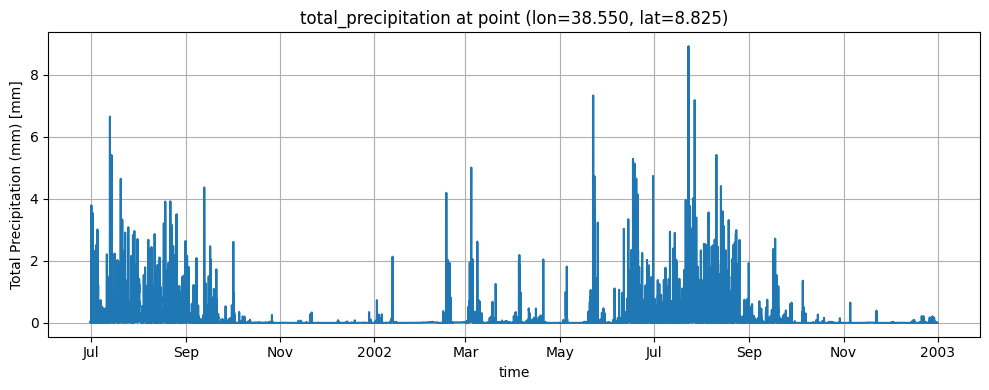

In [10]:
# --- 1. Point time series --------------------------------------------------

# 👉 Set the point coordinates (lon / lat) for the time series
pt_lon = float(da.x.mean().values)  # for convenience, use domain centre
pt_lat = float(da.y.mean().values)

print(f"Using point (lon={pt_lon:.3f}, lat={pt_lat:.3f}) for time series.")
ts_point = da.sel(x=pt_lon, y=pt_lat, method="nearest")

print(ts_point)

fig, ax = plt.subplots(figsize=(10, 4))
ts_point.plot(ax=ax)
ax.set_title(f"{var_name} at point (lon={pt_lon:.3f}, lat={pt_lat:.3f})")
ax.grid(True)
plt.tight_layout()
plt.show()

We can also do basin averages (or sums, which are useful for precipitation) and plot those time-series

<xarray.DataArray 'total_precipitation' (time: 13176)> Size: 105kB
dask.array<mean_agg-aggregate, shape=(13176,), dtype=float64, chunksize=(744,), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 105kB 2001-07-01 ... 2002-12-31T23:00:00
    spatial_ref  int64 8B 0
    band         int64 8B 1
Attributes: (12/14)
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/daily/ERA5/2001/chirps-v3.0....
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2025:01:08 09:49:28
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    ...                        ...
    source_key:                /home/idrologia/share/IWRM/CHIRPS/2001/07/CHIR...
    time:                      2001-07-01
    time_produced:             2025-11-14 01:36:32
    AREA_OR_POINT:             Area
    long_name:                 Total Precipitation (mm)
    units:                     mm

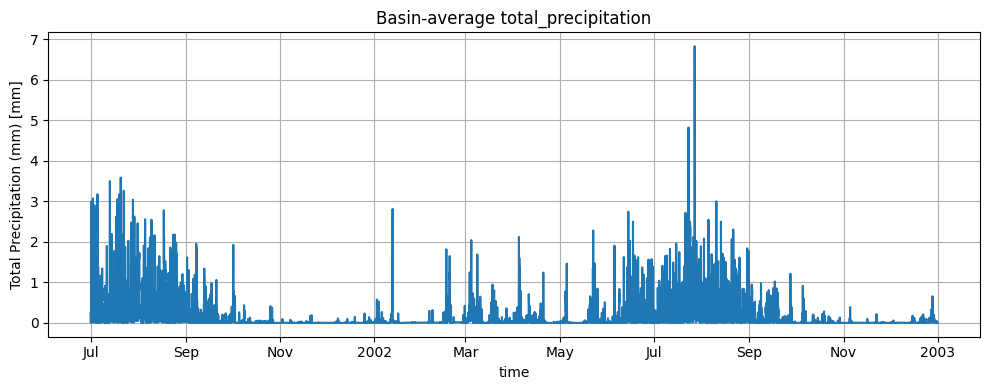

In [11]:
# --- 2. Basin‑average time series -----------------------------------------

basin_mask = get_basin_mask_on_grid(da)

# Mask out cells outside the basin
da_basin = da.where(basin_mask)

# Basin average (simple unweighted mean)
ts_basin = da_basin.mean(dim=("y", "x"))
#ts_basin = da_basin.sum(dim=("y", "x")) # or sum...
#ts_basin = np.cumsum(da_basin.mean(dim=("y", "x")))     #cumulative precipitation

print(ts_basin)

fig, ax = plt.subplots(figsize=(10, 4))
ts_basin.plot(ax=ax)
ax.set_title(f"Basin‑average {var_name}")
ax.grid(True)
plt.tight_layout()
plt.show()

## 🗺️ Spatial maps over a sub‑period

Here we compute:

- the **mean** value map over a sub‑period (for most variables);
- the **cumulative** map over the same period for `total_precipitation`.


Loading 18 file(s) for variable 'total_precipitation'...
Loaded dataset with 13176 time steps.
Sub‑period: 2001-07-01T00:00:00.000000000 → 2002-12-31T23:00:00.000000000
Number of timesteps in sub‑period: 13176


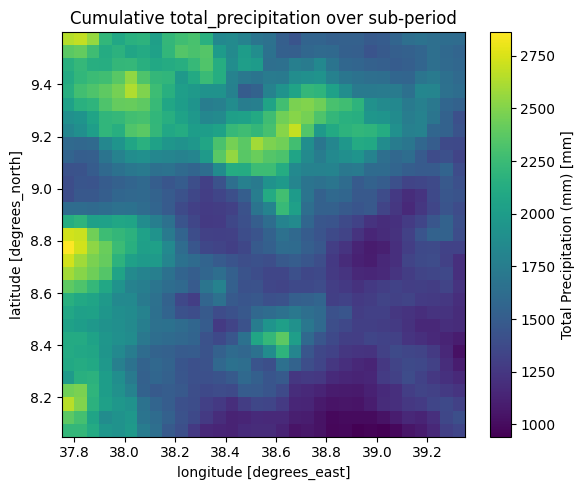

In [14]:
# 👉 Select the variable (must correspond to generated files)
var_name_map = "total_precipitation"

da_map = load_forcing_variable(var_name_map)

# 👉 Define a sub‑period (use ISO strings compatible with xarray)
sub_start = "2001-07-01 00:00"
sub_end   = "2022-12-31 23:00"

da_sub = da_map.sel(time=slice(sub_start, sub_end))

if da_sub.time.size == 0:
    raise ValueError("No data in the selected sub‑period; check dates and available files.")

print(f"Sub‑period: {str(da_sub.time.values[0])} → {str(da_sub.time.values[-1])}")
print(f"Number of timesteps in sub‑period: {da_sub.time.size}")

if var_name_map == "total_precipitation":
    agg_da = da_sub.sum(dim="time")
    title = f"Cumulative {var_name_map} over sub‑period"
else:
    agg_da = da_sub.mean(dim="time")
    title = f"Mean {var_name_map} over sub‑period"

fig, ax = plt.subplots(figsize=(6, 5))
agg_da.plot(ax=ax)
ax.set_title(title)
plt.tight_layout()
plt.show()

We can also visually compare the variable over different timesteps

In [15]:
# Compare the forcing between a list of selected timesteps
var_name_map = "temperature"
user_times = ("2022-07-01 00:00",
              "2022-07-01 06:00",
              "2022-07-01 12:00",
              "2022-07-01 18:00",
              "2022-07-02 00:00",
              "2022-07-02 06:00")

# --------------------------------------
# Load data and convert user input
# --------------------------------------
da_map = load_forcing_variable(var_name_map)

# Normalize user input into a list of times
user_times = [ i for i in user_times]

# extract selected time(s)
da_sel = da_map.sel(time=user_times)
times = list(da_sel.time.values)

# Apply mask
da_sel = da_sel.where(basin_mask)

if da_sel.time.size == 0:
    raise ValueError("No matching data for the selected times.")

print(f"Number of selected timesteps: {len(times)}")

# --------------------------------------
# Determine mosaic layout
# --------------------------------------

n = len(times)
cols = int(np.ceil(np.sqrt(n)))
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).reshape(rows, cols)

# --------------------------------------
# Plot each timestep in the mosaic
# --------------------------------------

for ax, t in zip(axes.flat, times):
    frame = da_sel.sel(time=t)

    frame.plot(ax=ax)
    ax.set_title(str(np.datetime_as_string(t)))
    ax.set_xlabel("")
    ax.set_ylabel("")

# Remove unused axes (if any)
for ax in axes.flat[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Loading 18 file(s) for variable 'temperature'...
Loaded dataset with 13176 time steps.


KeyError: "not all values found in index 'time'"

---

## ✅ Notes

- The notebook is designed to be **generic**: you only need to adjust
  the file templates and, if needed, the location of the choice raster.
- You can easily add:
  - more derived variables,
  - additional plots (e.g. monthly statistics, boxplots),
  - exports to CSV or other formats for external tools.

Feel free to modify and extend this workflow as needed for other basins or projects.
